In [ ]:
pip install keras tensorflow

In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


**Simple CNN Implemented using Keras.**

Task 1: Data Understanding and Visualization:
Download the Provided Data and Complete the following task.

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.

• Expected Output:

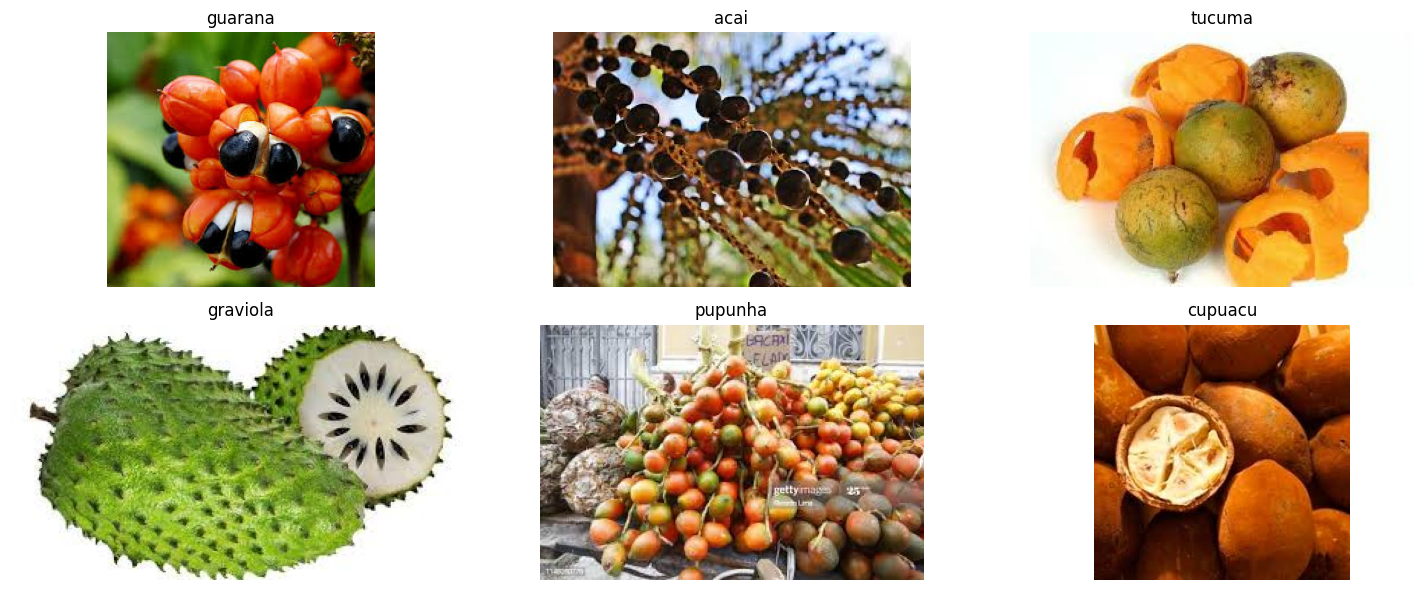

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define the path to the training directory
train_dir = '/content/drive/MyDrive/FruitinAmazon/train' # Replace with your actual path

# 1. Get the list of class directories from the train folder
class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

# 2. Select one image randomly from each class
selected_images = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    # Get a list of all images in the class directory
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if images:
        # Select a random image
        random_image = random.choice(images)
        selected_images.append((class_name, os.path.join(class_path, random_image)))

# 3. Display the images in a grid format with two rows using matplotlib
num_images = len(selected_images)
# Calculate the number of columns needed for 2 rows
num_cols = (num_images + 1) // 2

fig, axes = plt.subplots(2, num_cols, figsize=(15, 6))
axes = axes.flatten() # Flatten the 2D axes array for easier iteration

for i, (class_name, img_path) in enumerate(selected_images):
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis('off') # Hide the axes ticks

# Hide any extra empty subplots if the number of classes is odd
for j in range(len(selected_images), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [7]:
from PIL import Image
import os

corrupted_images = []
# Iterate through each class subdirectory
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            try:
                # Attempt to open and verify the image
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, SyntaxError):
                # If corrupted, remove and log
                os.remove(image_path)
                corrupted_images.append(image_path)
                print(f"Removed corrupted image: {image_path}")

if not corrupted_images:
  print("No Corrupted Images Found.")
else:
  print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


**Task 2: Loading and Preprocessing Image Data**

In [2]:
import tensorflow as tf

img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2

# Define the path to the training directory (added for fix)
train_dir = '/content/drive/MyDrive/FruitinAmazon/train' # Ensure this path is correct

# Training Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Validation Dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Normalization (Rescaling)
rescale = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


**Task 3: Implement a CNN**

In [4]:
from tensorflow.keras import layers, models
import os

# Assuming 'train_dir' is defined in a previous cell and accessible
# If 'train_dir' is not accessible, you would need to define it here, e.g.:
# train_dir = '/content/drive/MyDrive/FruitinAmazon/train'

# Get the number of classes by listing subdirectories in the train folder
class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
num_classes = len(class_names)

model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Fully Connected Network
    layers.Flatten(),
    layers.Dense(128, activation='relu'), # Chosen 128 as the hidden neuron count
    layers.Dense(num_classes, activation='softmax') # Output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Task 4: Compile and Train the Model**

In [5]:
# Model Compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Training
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    ModelCheckpoint('best_model.h5', save_best_only=True),
    EarlyStopping(patience=10, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    # Note: Dataset is already batched at 32 above;
    # to strictly use 16, re-run Task 2 with batch_size=16.
    callbacks=callbacks
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1649 - loss: 2.4393

3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.1667 - loss: 2.6997 - val_accuracy: 0.8333 - val_loss: 0.9302
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 874ms/step - accuracy: 0.1667 - loss: 1.7287 - val_accuracy: 0.2778 - val_loss: 1.4755
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 490ms/step - accuracy: 0.5417 - loss: 1.3600 - val_accuracy: 0.5556 - val_loss: 1.3347
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.5596 - loss: 1.2075

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 624ms/step - accuracy: 0.5694 - loss: 1.1448 - val_accuracy: 0.8333 - val_loss: 0.7920
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.7459 - loss: 0.8069

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 650ms/step - accuracy: 0.7222 - loss: 0.8142 - val_accuracy: 0.6667 - val_loss: 0.7673
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.6713 - loss: 0.7081

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 620ms/step - accuracy: 0.6389 - loss: 0.7375 - val_accuracy: 0.8889 - val_loss: 0.5624
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 838ms/step - accuracy: 0.9583 - loss: 0.3910 - val_accuracy: 0.8333 - val_loss: 0.6153
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.9497 - loss: 0.3797

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 944ms/step - accuracy: 0.9583 - loss: 0.3584 - val_accuracy: 0.8889 - val_loss: 0.4319
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9902 - loss: 0.1598

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 598ms/step - accuracy: 0.9861 - loss: 0.1743 - val_accuracy: 0.8333 - val_loss: 0.4269
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9699 - loss: 0.1298

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 550ms/step - accuracy: 0.9722 - loss: 0.1237 - val_accuracy: 0.8333 - val_loss: 0.3594
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 487ms/step - accuracy: 1.0000 - loss: 0.0494 - val_accuracy: 0.8333 - val_loss: 0.4056
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 476ms/step - accuracy: 1.0000 - loss: 0.0274 - val_accuracy: 0.8333 - val_loss: 0.5027
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 859ms/step - accuracy: 1.0000 - loss: 0.0167 - val_accuracy: 0.8333 - val_loss: 0.4890
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 851ms/step - accuracy: 1.0000 - loss: 0.0079 - val_accuracy: 0.8333 - val_loss: 0.3698
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 1.0000 - loss: 0.0047

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 581ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.8333 - val_loss: 0.3387
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 611ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.8333 - val_loss: 0.3788
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8333 - val_loss: 0.4097
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 551ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8333 - val_loss: 0.4282
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 773ms/step - accuracy: 1.0000 - loss: 9.3793e-04 - val_accuracy: 0.8333 - val_loss: 0.4263
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 848ms/step - accuracy: 1.0000 - loss: 7.5275e-04 - val_accuracy: 0.8333 - val_loss: 0.4178
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 481ms/step - accuracy: 1.0000 - loss: 6.2138e-04 - val_accuracy: 0.8333 - val_loss: 0.4091
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 546ms/step - accuracy: 1.0000 - loss: 5.4809e-04 - val_accuracy:

**Task 5 -Evaluate the model**

In [8]:
# Task 5: Evaluation
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.8333 - loss: 0.3387
Validation Accuracy: 0.8333


**Task 6: Save and Load the Model**

In [9]:
import numpy as np
from sklearn.metrics import classification_report

# Task 6: Save and Load
model.save('final_model.h5')
new_model = tf.keras.models.load_model('final_model.h5')

**Task 7: Predictions and Report**

In [10]:
# Task 7: Predictions and Report
y_true = np.concatenate([y for x, y in val_ds], axis=0)
predictions = new_model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         0
           4       1.00      0.67      0.80         3
           5       1.00      0.87      0.93        15

    accuracy                           0.83        18
   macro avg       0.50      0.38      0.43        18
weighted avg       1.00      0.83      0.91        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
